# Vérification de la distribution des paramètres du calage Gaussien linéaire

## Introduction

L'objectif de ce document est de vérifier la distribution de la solution du problème de calage linéaire Gaussien. Plus précisément, on vérifie que les méthodes `getObservationsError` et `getParameterPosterior` de la classe `GaussianLinearCalibration` sont correctes.

On considère ici un modèle *exactement* linéaire. 

La méthode de vérification est présentée dans "Vérification des moindres carrés linéaires". 

## Définit le modèle

In [1]:
import numpy as np
import openturns as ot
import pylab as pl
import openturns.viewer as otv
import otcalibration as otc
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.size"] = "12"

Dans la cellule suivante, on configure le modèle physique et la valeur "vraie" du paramètre. 

In [2]:
ot.RandomGenerator.SetSeed(0)

g = ot.SymbolicFunction(
    ["x", "theta1", "theta2", "theta3"], ["theta1 + theta2 * x + theta3 * x^2"]
)
g.setInputDescription(["X", r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"])
g.setOutputDescription(["Y"])

trueParameter = ot.Point([12.0, 7.0, -8.0])
print("trueParameter = ", trueParameter)

parameterDimension = trueParameter.getDimension()
print("Dimension = ", parameterDimension)

trueParameter =  [12,7,-8]
Dimension =  3


On génère ensuite l'échantillon des entrées observées. On considère un échantillon de taille `size`. Puis on définit la fonction paramétrique utilisée pour le calage. 

In [3]:
size = 100
data = np.linspace(-1.0, 1.0, size)
inputObservations = ot.Sample([[v] for v in data])

calibratedIndices = [1, 2, 3]
model = ot.ParametricFunction(g, calibratedIndices, trueParameter)

On utilise un bruit d'observation de loi Gaussienne de moyenne nulle et d'écart-type égal à 2. On génère ensuite un échantillon d'observations de la sortie. 

In [4]:
outputObservationNoiseSigma = 2.0
observationOutputNoise = ot.Normal(0.0, outputObservationNoiseSigma)

outputStress = model(inputObservations)
# Ajoute le bruit
sampleNoiseH = observationOutputNoise.getSample(size)
outputObservations = outputStress + sampleNoiseH

La variable `candidate` est le point de référence du calage. 

candidate =  [8,9,-6]


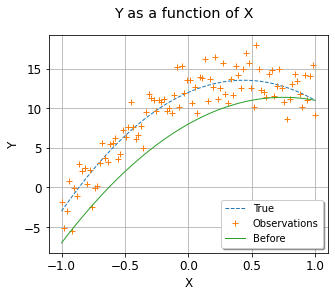

In [5]:
candidate = ot.Point([8.0, 9.0, -6.0])
print("candidate = ", candidate)
model.setParameter(trueParameter)
graph = model.draw(-1.0, 1.0)
curve = graph.getDrawable(0)
curve.setLegend("True")
curve.setLineStyle("dashed")
graph.setDrawable(curve, 0)
cloud = ot.Cloud(inputObservations, outputObservations)
cloud.setLegend("Observations")
graph.add(cloud)
model.setParameter(candidate)
curve = model.draw(-1.0, 1.0)
curve.setLegends(["Before"])
graph.add(curve)
graph.setColors(ot.Drawable_BuildDefaultPalette(3))
graph.setLegendPosition("bottomright")
view = otv.View(graph, figure_kw={"figsize": (5.0, 4.0)})

On observe que la courbe vraie est verticalement au centre du nuage de point et que la courbe avant calage est légèrement décalée vers le bas.

## Calage Gaussien linéaire

On fait le choix d'une distribution des erreurs d'observation différente de celle du bruit de mesure "vrai". On utilise un écart-type égal à 4, alors que la valeur "vraie" est égale à 2.

In [6]:
errorObservationNoiseSigma = 4.0
errorCovariance = ot.CovarianceMatrix(1)
errorCovariance[0, 0] = outputObservationNoiseSigma ** 2
print("errorCovariance = ", errorCovariance[0, 0])

errorCovariance =  4.0


Définit la matrice de covariance des paramètres $\theta$.

In [7]:
sigmaTheta1 = 0.1 * trueParameter[0]
sigmaTheta2 = 0.1 * trueParameter[1]
sigmaTheta3 = 0.1 * trueParameter[2]

parameterCovariance = ot.CovarianceMatrix(3)
parameterCovariance[0, 0] = sigmaTheta1 ** 2
parameterCovariance[1, 1] = sigmaTheta2 ** 2
parameterCovariance[2, 2] = sigmaTheta3 ** 2
print("parameterCovariance = ", parameterCovariance)

algo = ot.GaussianLinearCalibration(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
)
algo.run()
calibrationResult = algo.getResult()

parameterCovariance =  [[ 1.44 0    0    ]
 [ 0    0.49 0    ]
 [ 0    0    0.64 ]]


## Vérifie la distribution des résidus

On souhaite vérifier la distribution des résidus obtenus avec la méthode `getObservationsError`.

In [8]:
residualDistribution = calibrationResult.getObservationsError()
print("residualDistribution = ", residualDistribution)

sigma = residualDistribution.getParameter()[1]

residualDistribution =  Normal(mu = 0, sigma = 2)


On souhaite observer la distribution empirique de l'échantillon du résidu. 

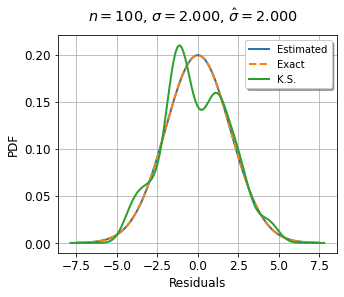

In [9]:
residualFunction = calibrationResult.getResidualFunction()
thetaMAP = calibrationResult.getParameterMAP()
residualPoint = residualFunction(thetaMAP)
residualSample = ot.Sample([[v] for v in residualPoint])
kernel = ot.KernelSmoothing()
fittedDist = kernel.build(residualSample)

graph = residualDistribution.drawPDF()
graph.setLegends(["Estimated"])
graphExact = observationOutputNoise.drawPDF().getDrawable(0)
graphExact.setLegend("Exact")
graphExact.setLineStyle("dashed")
graph.add(graphExact)
residualPDF = fittedDist.drawPDF()
residualPDF.setLegends(["K.S."])
graph.add(residualPDF)
graph.setTitle(
    "$n=%d$, $\sigma=%.3f$, $\hat{\sigma}=%.3f$"
    % (size, outputObservationNoiseSigma, sigma)
)
graph.setLegendPosition("topright")
graph.setXTitle("Residuals")
graph.setColors(ot.Drawable_BuildDefaultPalette(3))
view = otv.View(graph, figure_kw={"figsize": (5.0, 4.0)})

La distribution des résidus est une hypothèse de calcul, c'est pourquoi la distribution exacte et la distribution estimée coïncident nécessairement. Cela explique pourquoi les courbes "Estimated" et "Exact" sont superposées. On observe que la distribution empirique des résidus estimée par lissage à noyau  (K.S.) correspond à la distribution attendue.

## Convergence selon la taille de l'échantillon

On souhaite observer le comportement de l'estimation lorsque la taille de l'échantillon augmente.

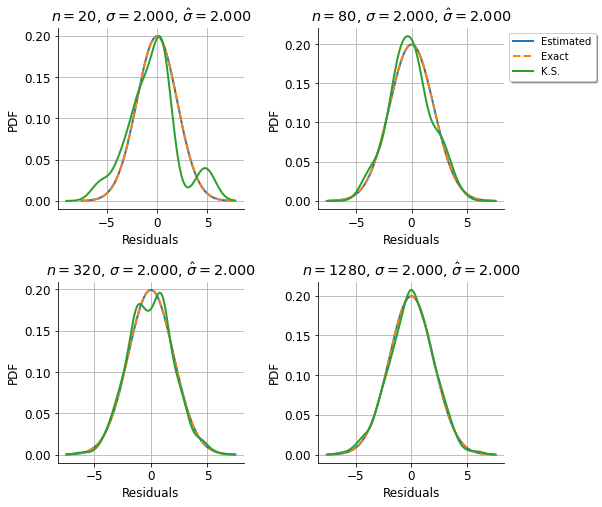

In [10]:
def simulate_and_plot_residuals(size, model, trueParameter, candidate):
    """
    Simule un échantillon et dessine la distribution des résidus.

    Parameters
    ----------
    size : int
        La taille de l'échantillon.

    Returns
    -------
    graph : ot.Graph
        Le graphique des résidus.
    """
    data = np.linspace(-1.0, 1.0, size)
    inputObservations = ot.Sample([[v] for v in data])
    calibratedIndices = [1, 2, 3]
    model = ot.ParametricFunction(g, calibratedIndices, trueParameter)

    # On utilise un bruit d'observation de loi Gaussienne de moyenne nulle et d'écart-type égal à 2.
    outputObservationNoiseSigma = 2.0
    observationOutputNoise = ot.Normal(0.0, outputObservationNoiseSigma)
    outputStress = model(inputObservations)
    # 2. Add noise
    sampleNoiseH = observationOutputNoise.getSample(size)
    outputObservations = outputStress + sampleNoiseH
    candidate = ot.Point([8.0, 9.0, -6.0])

    # Calage Gaussien linéaire
    errorObservationNoiseSigma = 4.0
    errorCovariance = ot.CovarianceMatrix(1)
    errorCovariance[0, 0] = outputObservationNoiseSigma ** 2

    # Define the covariance matrix of the parameters $\theta$ to calibrate.
    sigmaTheta1 = 0.1 * trueParameter[0]
    sigmaTheta2 = 0.1 * trueParameter[1]
    sigmaTheta3 = 0.1 * trueParameter[2]
    parameterCovariance = ot.CovarianceMatrix(3)
    parameterCovariance[0, 0] = sigmaTheta1 ** 2
    parameterCovariance[1, 1] = sigmaTheta2 ** 2
    parameterCovariance[2, 2] = sigmaTheta3 ** 2

    algo = ot.GaussianLinearCalibration(
        model,
        inputObservations,
        outputObservations,
        candidate,
        parameterCovariance,
        errorCovariance,
    )
    algo.run()
    calibrationResult = algo.getResult()
    residualDistribution = calibrationResult.getObservationsError()
    sigma = residualDistribution.getParameter()[1]

    # Distribution empirique de l'échantillon du résidu.
    residualFunction = calibrationResult.getResidualFunction()
    thetaMAP = calibrationResult.getParameterMAP()
    residualPoint = residualFunction(thetaMAP)
    residualSample = ot.Sample([[v] for v in residualPoint])
    kernel = ot.KernelSmoothing()
    fittedDist = kernel.build(residualSample)

    graph = residualDistribution.drawPDF()
    graph.setLegends(["Estimated"])
    graph.setXTitle("Residuals")
    graphExact = observationOutputNoise.drawPDF().getDrawable(0)
    graphExact.setLegend("Exact")
    graphExact.setLineStyle("dashed")
    graph.add(graphExact)
    residualPDF = fittedDist.drawPDF()
    residualPDF.setLegends(["K.S."])
    graph.add(residualPDF)
    graph.setTitle(
        "$n=%d$, $\sigma=%.3f$, $\hat{\sigma}=%.3f$"
        % (size, outputObservationNoiseSigma, sigma)
    )
    graph.setLegendPosition("topright")
    graph.setColors(ot.Drawable_BuildDefaultPalette(3))
    return graph

grid = ot.GridLayout(2, 2)
graph = simulate_and_plot_residuals(20, model, trueParameter, candidate)
graph.setLegends([""])
grid.setGraph(0, 0, graph)
graph = simulate_and_plot_residuals(80, model, trueParameter, candidate)
grid.setGraph(0, 1, graph)
graph = simulate_and_plot_residuals(320, model, trueParameter, candidate)
graph.setLegends([""])
grid.setGraph(1, 0, graph)
graph = simulate_and_plot_residuals(1280, model, trueParameter, candidate)
graph.setLegends([""])
grid.setGraph(1, 1, graph)
view = otv.View(grid, figure_kw={"figsize": (8.0, 8.0)}, 
               legend_kw={"bbox_to_anchor":(1.0, 1.0), "loc":"upper left"})
pl.subplots_adjust(wspace=0.4, hspace=0.4)

On observe que la distribution des résidus converge vers la vraie distribution lorsque la taille de l'échantillon augmente. 

## Vérifie la distribution du vecteur des paramètres

La classe `LinearGaussianCalibrationRandomVector` crée un vecteur aléatoire associé à l'estimateur du vecteur des paramètres.

In [11]:
linearGaussianRandomVector = otc.LinearGaussianCalibrationRandomVector(
    model,
    trueParameter,
    inputObservations,
    observationOutputNoise,
    candidate,
    parameterCovariance,
    errorCovariance,
)
linearGaussianRandomVector =  ot.RandomVector(linearGaussianRandomVector)
resampleSize = 500
sampleTheta = linearGaussianRandomVector.getSample(resampleSize)
sampleTheta[0:5]

class=Sample name=Unnamed implementation=class=SampleImplementation name=Unnamed size=5 dimension=3 description=[x0,x1,x2] data=[[11.468,7.71579,-6.85079],[11.2486,7.24019,-7.04755],[11.2086,7.88539,-6.73907],[11.3341,7.56325,-6.68514],[11.8801,7.74076,-6.75379]]

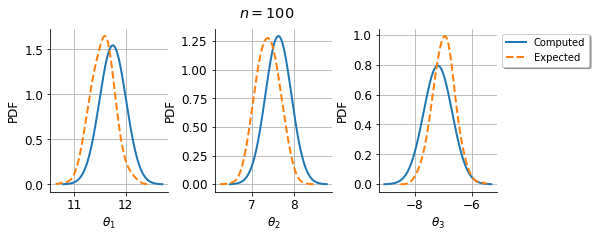

In [12]:
thetaPosterior = calibrationResult.getParameterPosterior()

distributionTheta = ot.KernelSmoothing().build(sampleTheta)
grid = ot.GridLayout(1, parameterDimension)
for i in range(parameterDimension):
    thetai = thetaPosterior.getMarginal(i)
    graph = thetai.drawPDF()
    graph.setLegends(["Computed"])
    # From data
    curve = distributionTheta.getMarginal(i).drawPDF()
    curve = curve.getDrawable(0)
    curve.setLegend("Expected")
    curve.setLineStyle("dashed")
    graph.add(curve)
    if i != parameterDimension - 1:
        graph.setLegends([""])
    graph.setColors(ot.Drawable_BuildTableauPalette(2))
    grid.setGraph(0, i, graph)
grid.setTitle("$n=%d$" % (size))
view = otv.View(grid, figure_kw={"figsize": (8.0, 3.0)}, 
               legend_kw={"bbox_to_anchor":(1.0, 1.0), "loc":"upper left"})
pl.subplots_adjust(wspace=0.4, hspace=0.4)

On observe que les deux distributions sont proches. La différence dans l'estimation du centre est dûe à la taille limitée de l'échantillon. La variance est correctement estimée.

## Convergence selon la taille de l'échantillon

On souhaite observer le comportement de l'estimation lorsque la taille de l'échantillon augmente.

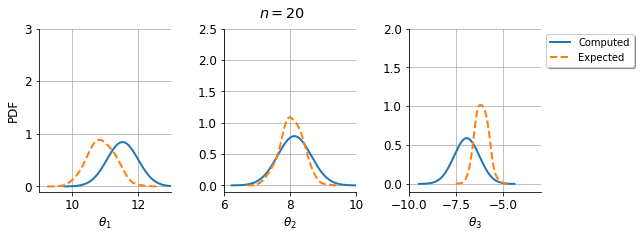

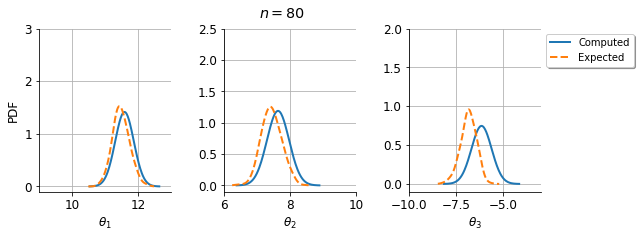

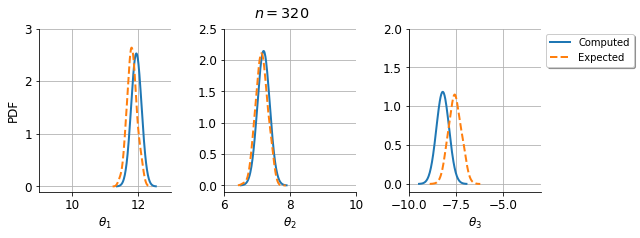

In [13]:
def simulate_and_plot(size, resampleSize=500):
    trueParameter = ot.Point([12.0, 7.0, -8.0])
    parameterDimension = trueParameter.getDimension()
    data = np.linspace(-1.0, 1.0, size)
    inputObservations = ot.Sample([[v] for v in data])
    calibratedIndices = [1, 2, 3]
    model = ot.ParametricFunction(g, calibratedIndices, trueParameter)
    outputObservationNoiseSigma = 2.0
    observationOutputNoise = ot.Normal(0.0, outputObservationNoiseSigma)
    outputStress = model(inputObservations)
    sampleNoiseH = observationOutputNoise.getSample(size)
    outputObservations = outputStress + sampleNoiseH
    candidate = ot.Point([8.0, 9.0, -6.0])
    model.setParameter(trueParameter)
    errorCovariance = ot.CovarianceMatrix(1)
    errorCovariance[0, 0] = outputObservationNoiseSigma ** 2
    sigmaTheta1 = 0.1 * trueParameter[0]
    sigmaTheta2 = 0.1 * trueParameter[1]
    sigmaTheta3 = 0.1 * trueParameter[2]
    parameterCovariance = ot.CovarianceMatrix(3)
    parameterCovariance[0, 0] = sigmaTheta1 ** 2
    parameterCovariance[1, 1] = sigmaTheta2 ** 2
    parameterCovariance[2, 2] = sigmaTheta3 ** 2
    algo = ot.GaussianLinearCalibration(
        model,
        inputObservations,
        outputObservations,
        candidate,
        parameterCovariance,
        errorCovariance,
    )
    algo.run()
    calibrationResult = algo.getResult()
    linearGaussianRandomVector = otc.LinearGaussianCalibrationRandomVector(
        model,
        trueParameter,
        inputObservations,
        observationOutputNoise,
        candidate,
        parameterCovariance,
        errorCovariance,
    )
    linearGaussianRandomVector =  ot.RandomVector(linearGaussianRandomVector)
    sampleTheta = linearGaussianRandomVector.getSample(resampleSize)
    thetaPosterior = calibrationResult.getParameterPosterior()
    distributionTheta = ot.KernelSmoothing().build(sampleTheta)
    grid = ot.GridLayout(1, parameterDimension)
    list_of_bounding_boxes = [
        ot.Interval([9.0, -0.1], [13.0, 3.0]), 
        ot.Interval([6.0, -0.1], [10.0, 2.5]), 
        ot.Interval([-10.0, -0.1], [-3.0, 2.0]), 
    ]
    for i in range(parameterDimension):
        thetai = thetaPosterior.getMarginal(i)
        graph = thetai.drawPDF()
        graph.setLegends(["Computed"])
        # From data
        curve = distributionTheta.getMarginal(i).drawPDF()
        curve = curve.getDrawable(0)
        curve.setLegend("Expected")
        curve.setLineStyle("dashed")
        graph.add(curve)
        if i > 0:
            graph.setYTitle("")
        if i != parameterDimension - 1:
            graph.setLegends([""])
        graph.setColors(ot.Drawable_BuildTableauPalette(2))
        graph.setBoundingBox(list_of_bounding_boxes[i])
        grid.setGraph(0, i, graph)
    grid.setTitle("$n=%d$" % (size))
    view = otv.View(
        grid,
        figure_kw={"figsize": (9.0, 3.0)},
        legend_kw={"bbox_to_anchor": (1.0, 1.0), "loc": "upper left"},
    )
    pl.subplots_adjust(wspace=0.4, hspace=0.4)
    return view


view = simulate_and_plot(20)
view = simulate_and_plot(80)
view = simulate_and_plot(320)

On observe que la distribution est de plus en plus resserrée lorsque la taille de l'échantillon augmente.